# Customer Trend Analysis K-Means clustring

In [521]:
 ## Importing nessary libererries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [523]:
cust_data = pd.read_csv(r'H:\Data\customer_shopping_behavior.csv')

## 1. Data Preprossecing (Data Loading and Initial Understanding).

In [526]:
cust_data.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [528]:
cust_data.shape

(3900, 18)

In [530]:
cust_data.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [532]:
cust_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [534]:
cust_data.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [536]:
cust_data['Review Rating'] = cust_data.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [538]:
cust_data

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [540]:
cust_data.describe( include = 'all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750051,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.713590,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [542]:
cust_data.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750051,25.351538
std,1125.977353,15.207589,23.685392,0.713590,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


## Data Cleaning and Column Fixes

In [438]:
cust_data.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [545]:
cust_data.columns = cust_data.columns.str.lower()
cust_data.columns = cust_data.columns.str.replace(' ', '_')
cust_data = cust_data.rename(columns = {'purchase-amount-(usd)':'purchase_amount'})
cust_data.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [547]:
cust_data = cust_data.rename(columns={'purchase_amount_(usd)' : 'purchase_amount'})
cust_data.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

## Feature Engineering

In [550]:
labels = ['young_adult', 'adult', 'middel_age', 'senior']

cust_data['age_group'] = pd.qcut(cust_data['age'], q=4, labels = labels)

In [552]:
cust_data[['age','age_group']].head(10)

,age,age_group
0,55,middel_age
1,19,young_adult
2,50,middel_age
3,21,young_adult
4,45,middel_age
5,46,middel_age
6,63,senior
7,27,young_adult
8,26,young_adult
9,57,middel_age


In [554]:
cust_data['frequency_of_purchases'].unique()

array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)

In [556]:
frequency_mapping = {'Fortnightly':14,
                    'Weekly':7,
                     'Quarterly':90,
                    'Annually':365,
                    'Every 3 Months': 90,
                    'Bi-Weekly': 14,
                    'Monthly': 30,
                    }
cust_data['purchase_of_frequency_days']=cust_data['frequency_of_purchases'].map(frequency_mapping)

In [558]:

cust_data[['purchase_of_frequency_days', 'frequency_of_purchases']].head(10)

,purchase_of_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [560]:
cust_data[['discount_applied', 'promo_code_used']]

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
...,...,...
3895,No,No
3896,No,No
3897,No,No
3898,No,No


In [562]:
(cust_data['discount_applied'] == cust_data['promo_code_used']).all()

True

In [564]:
cust_data = cust_data.drop('promo_code_used', axis=1)

In [566]:
cust_data.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_of_frequency_days'],
      dtype='object')

In [568]:

numeric_column=cust_data.select_dtypes(['float64', 'int64']).columns

## Exploretry Data Analysis.

In [571]:
numeric_column

Index(['customer_id', 'age', 'purchase_amount', 'review_rating',
       'previous_purchases', 'purchase_of_frequency_days'],
      dtype='object')

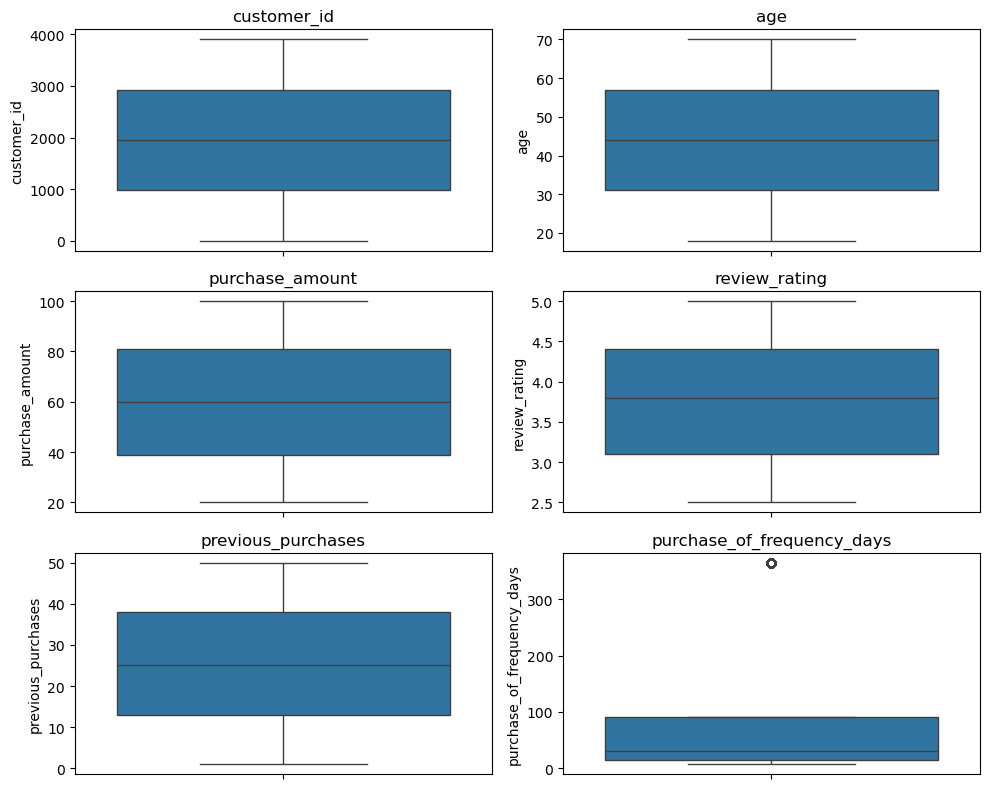

In [573]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))  # Adjust the size as necessary

for i, column in enumerate(numeric_column):
    ax = axs[i//2, i%2]  # Determines the position of the subplot in the grid
    sns.boxplot(cust_data[column], ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

## Customer Behavioral Variables 

In [577]:
cust_data.describe()

,customer_id,age,purchase_amount,review_rating,previous_purchases,purchase_of_frequency_days
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750051,25.351538,89.133077
std,1125.977353,15.207589,23.685392,0.713590,14.447125,119.037566
min,1.000000,18.000000,20.000000,2.500000,1.000000,7.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000,14.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000,30.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000,90.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000,365.000000


-- Age : in this variable most of the customers are between  18 years to 70 years of age, where median is 45 age meaning the majority 
customers are fall into a middle-aged, which is good for broad, general marketing, and data also showing the No extreme outliers, 
indicating clean and reliable age data.

-- Purchase Amount: Purchase Amount range from 20 to 100 unites, with no extream outlier amd median is 60 with symmetrical distriution, 
This indicates a consistent spending pattern across customers are no extreme high-spenders or low-spenders dominating the dataset.

-- Review Rating: Ratings vary from 2.5 to 5.0, with a median around 3.8, and the distribution is slightly right-skewed, meaning many customers leave positive reviews with no extreme outlier, where customer satisfaction appears healthy, with most users giving above-average ratings

-- Previous Purchases : Values range from 1 to 50 are previous purchases, many customers have fewer previous purchases, but a solid group of repeat buyers exists with high purchase counts, this slightly right skewd  first-time buyers and loyal repeat customers, useful for segmentation strategies,

-- Purchase Frequency : Most customers buy within 10–40 days, but there is one significant outlier around 360 days. this represent rarly purchaes by customer, need to remove for clustring.

## Outlier Detection and Treatment

In [594]:
cust_data.purchase_of_frequency_days.quantile([0.25,0.75])

0.25    14.0
0.75    90.0
Name: purchase_of_frequency_days, dtype: float64

In [596]:
Q1 = cust_data['purchase_of_frequency_days'].quantile(0.25)
Q3 = cust_data['purchase_of_frequency_days'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# removing outliers
cust_data = cust_data[
    (cust_data['purchase_of_frequency_days'] >= lower_bound) &
    (cust_data['purchase_of_frequency_days'] <= upper_bound)
]

cust_data.shape


(3328, 19)

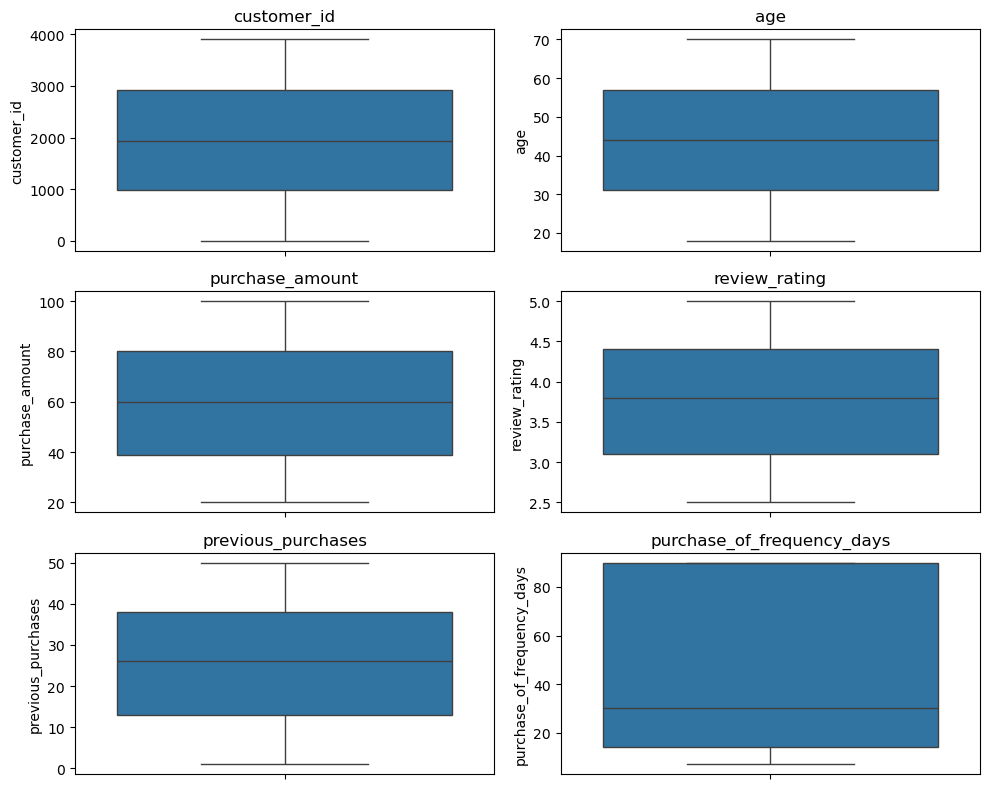

In [598]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))  # Adjust the size as necessary

for i, column in enumerate(numeric_column):
    ax = axs[i//2, i%2]  # Determines the position of the subplot in the grid
    sns.boxplot(cust_data[column], ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

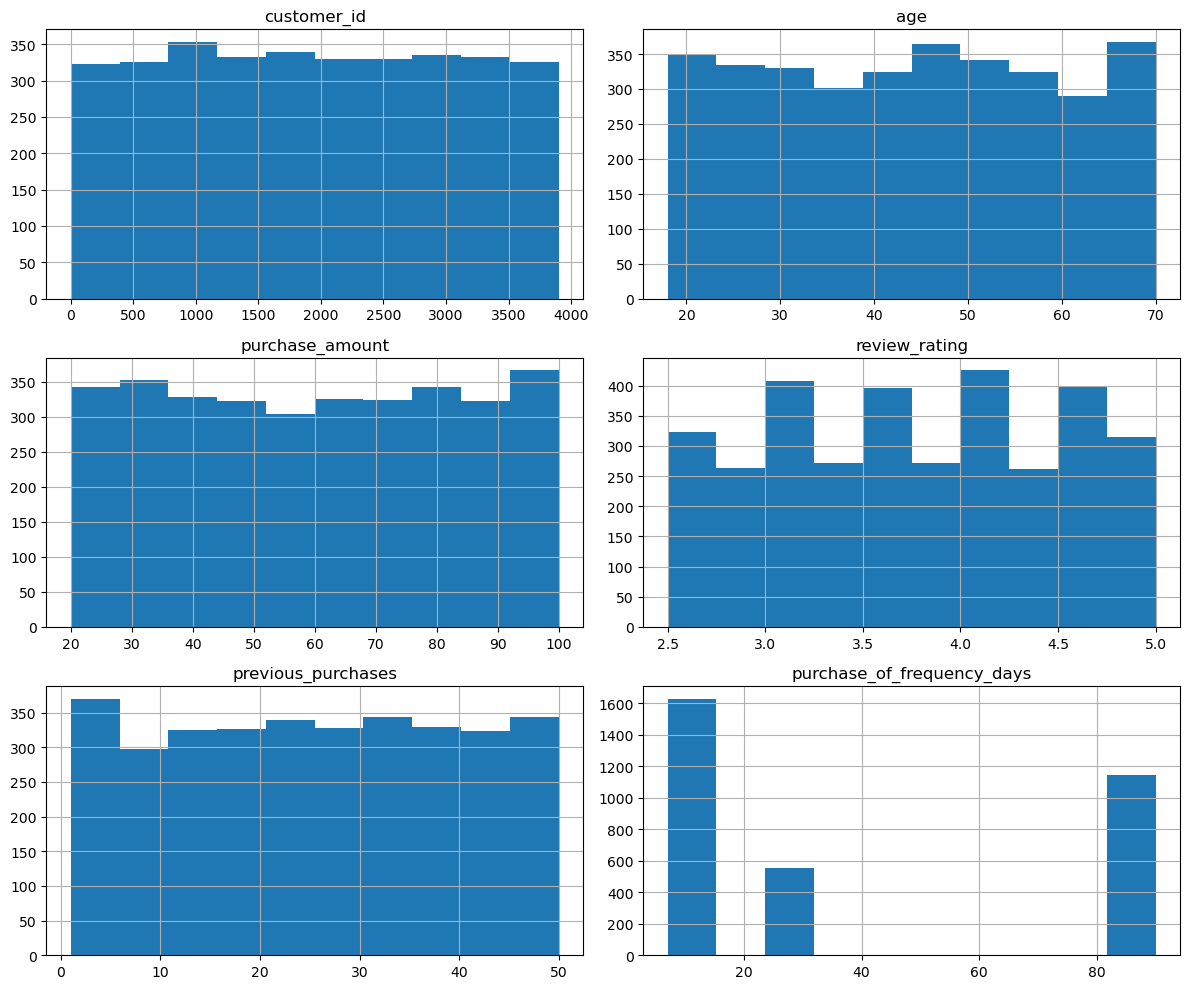

In [599]:
cust_data.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

In [457]:
cust_data.describe()

,customer_id,age,purchase_amount,review_rating,previous_purchases,purchase_of_fequancy_days
count,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000,3328.000000
mean,1948.738882,43.965745,59.694111,3.748798,25.487380,41.718450
std,1119.170025,15.159864,23.639148,0.714851,14.509011,35.682648
min,1.000000,18.000000,20.000000,2.500000,1.000000,7.000000
25%,979.750000,31.000000,39.000000,3.100000,13.000000,14.000000
50%,1939.500000,44.000000,60.000000,3.800000,26.000000,30.000000
75%,2926.250000,57.000000,80.000000,4.400000,38.000000,90.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000,90.000000


In [602]:
cust_data['gender'] = cust_data['gender'].map({'Male': 1, 'Female': 0})


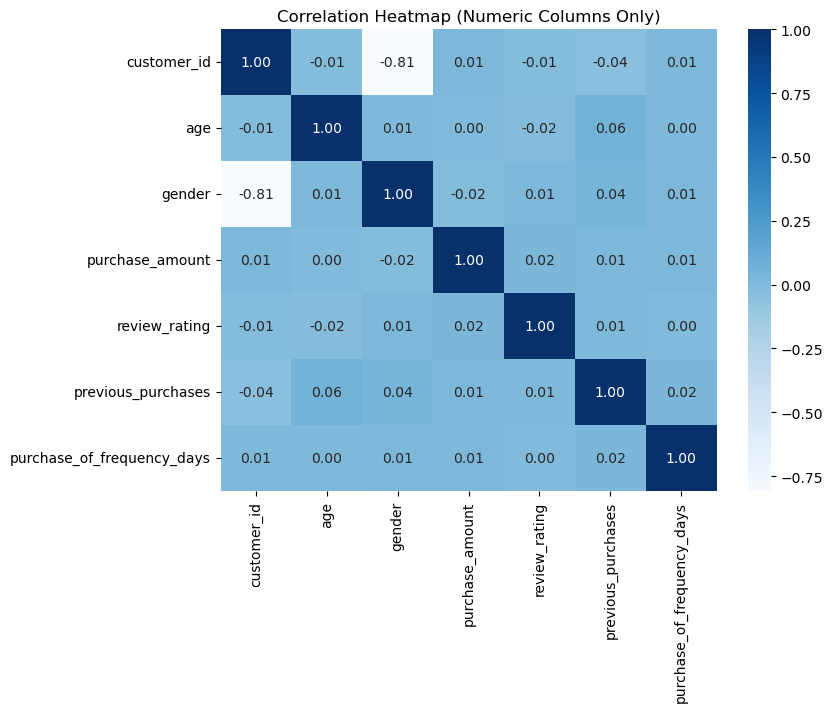

In [604]:

# Select only numeric columns
numeric_df = cust_data.select_dtypes(include=['int64', 'float64'])

# Create heatmap
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Columns Only)")
plt.show()


## Preparing Data for Clustering

In [607]:
from sklearn.preprocessing import StandardScaler

features = ['age', 'purchase_amount', 'previous_purchases', 'purchase_of_frequency_days']
X = cust_data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## K-Means Clustering

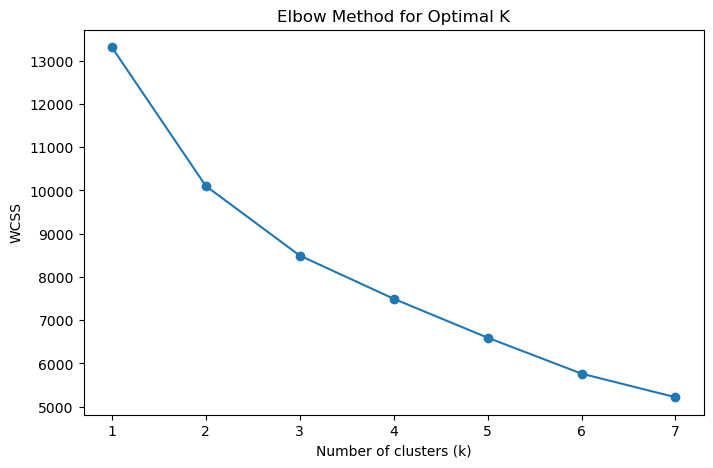

In [610]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []  # within cluster sum of squares

for k in range(1,8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 8), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.show()


In [612]:
kmeans = KMeans(n_clusters=3, random_state=42)
cust_data['cluster'] = kmeans.fit_predict(X_scaled)


In [614]:
cust_data.cluster.value_counts()

cluster
0    1147
1    1131
2    1050
Name: count, dtype: int64

In [616]:
cluster_summary = cust_data.groupby('cluster')[features].mean()
cluster_summary


,age,purchase_amount,previous_purchases,purchase_of_frequency_days
cluster,,,,
0,44.034874,60.034002,25.890148,90.000000
1,31.550840,59.019452,23.328912,16.423519
2,57.262857,60.049524,27.372381,16.222857


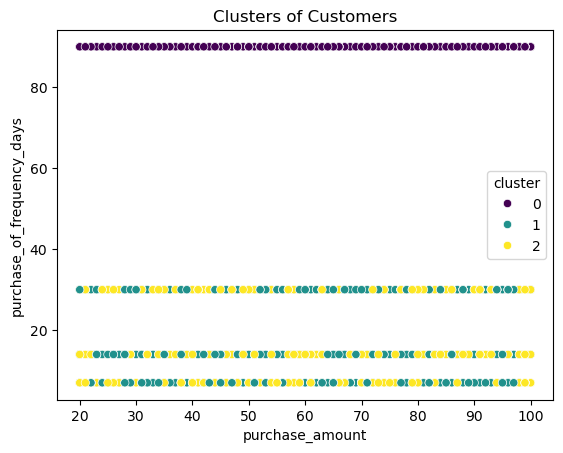

In [620]:
sns.scatterplot(
    x=cust_data['purchase_amount'], 
    y=cust_data['purchase_of_frequency_days'], 
    hue=cust_data['cluster'],
    palette='viridis'
)
plt.title("Clusters of Customers")
plt.show()


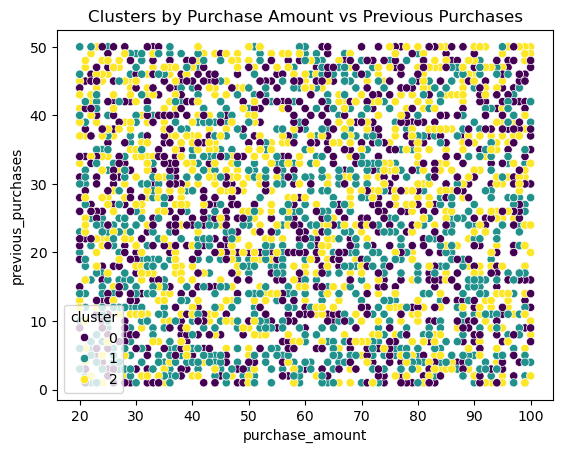

In [622]:
sns.scatterplot(
    x=cust_data['purchase_amount'],
    y=cust_data['previous_purchases'],
    hue=cust_data['cluster'],
    palette='viridis'
)
plt.title("Clusters by Purchase Amount vs Previous Purchases")
plt.show()


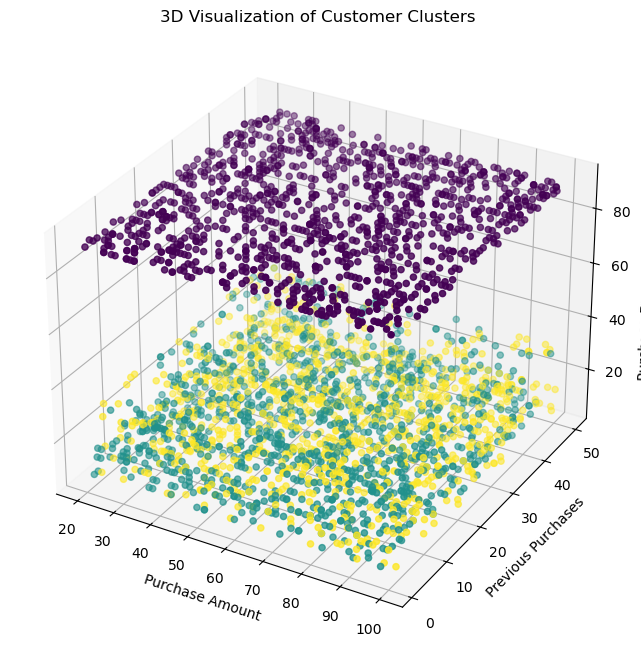

In [628]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    cust_data['purchase_amount'],
    cust_data['previous_purchases'],
    cust_data['purchase_of_frequency_days'],
    c=cust_data['cluster'],
    cmap='viridis'
)

ax.set_xlabel("Purchase Amount")
ax.set_ylabel("Previous Purchases")
ax.set_zlabel("Purchase Frequency (days)")
plt.title("3D Visualization of Customer Clusters")
plt.show()


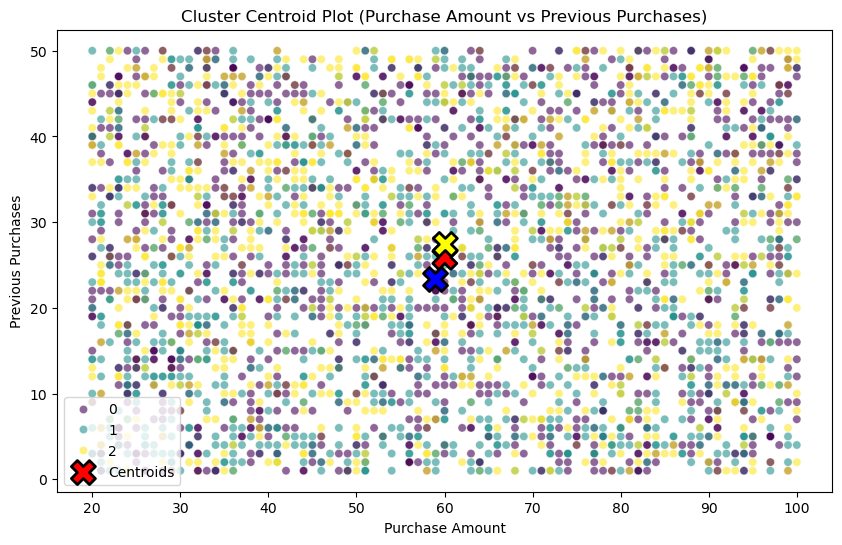

In [630]:
centroids = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids)

centroids_df = pd.DataFrame(centroids_original, columns=['age','purchase_amount','previous_purchases','purchase_of_fequency_days'])

plt.figure(figsize=(10,6))

sns.scatterplot(x=cust_data['purchase_amount'], y=cust_data['previous_purchases'], hue=cust_data['cluster'], palette='viridis',alpha=0.6)
plt.scatter(centroids_df['purchase_amount'], centroids_df['previous_purchases'], s=300, c=['red','blue','yellow'], marker='X', 
            edgecolor='black', linewidth=2,label='Centroids')

plt.title("Cluster Centroid Plot (Purchase Amount vs Previous Purchases)")
plt.xlabel("Purchase Amount")
plt.ylabel("Previous Purchases")
plt.legend()
plt.show()


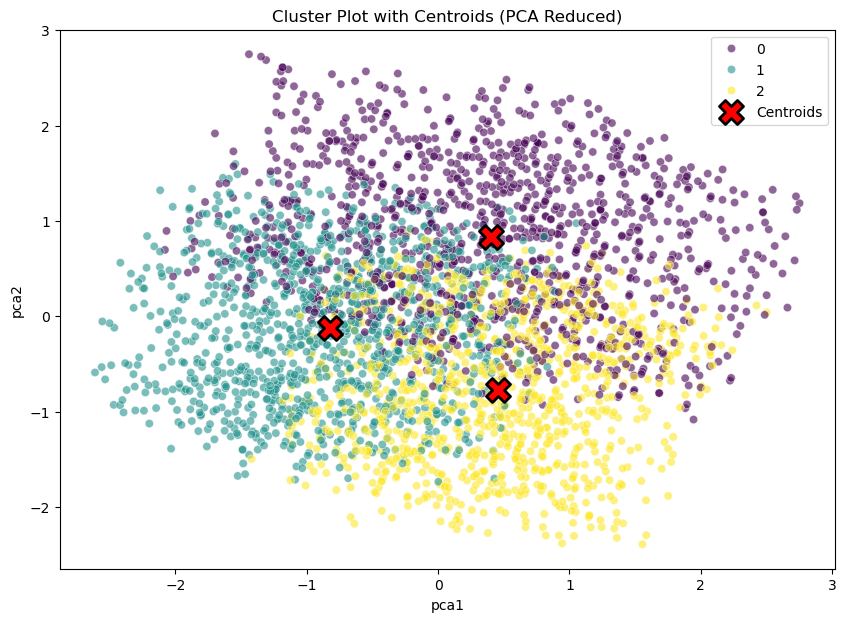

In [631]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

cust_data['pca1'] = X_pca[:, 0]
cust_data['pca2'] = X_pca[:, 1]

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.figure(figsize=(10,7))
sns.scatterplot( x='pca1', y='pca2', hue='cluster', data=cust_data, palette='viridis', alpha=0.6)
plt.scatter( centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='red',marker='X', edgecolor='black', linewidth=2, label='Centroids')
plt.title("Cluster Plot with Centroids (PCA Reduced)")
plt.legend()
plt.show()


In [634]:
numeric = cust_data.select_dtypes(include=['int64','float64']).columns
cust_data.groupby("cluster")[numeric].mean()


,customer_id,age,gender,purchase_amount,review_rating,previous_purchases,purchase_of_frequency_days,pca1,pca2
cluster,,,,,,,,,
0,1955.455100,44.034874,0.690497,60.034002,3.747864,25.890148,90.000000,0.399064,0.835331
1,1971.826702,31.550840,0.669319,59.019452,3.747215,23.328912,16.423519,-0.823942,-0.125340
2,1916.533333,57.262857,0.681905,60.049524,3.751524,27.372381,16.222857,0.451573,-0.777491


In [472]:
cluster_labels = {
    0: "Occasional Buyers",
    1: "Young Frequent Buyers",
    2: "Loyal Older Buyers"
}

cust_data["customer_persona"] = cust_data["cluster"].map(cluster_labels)


<Axes: xlabel='cluster'>

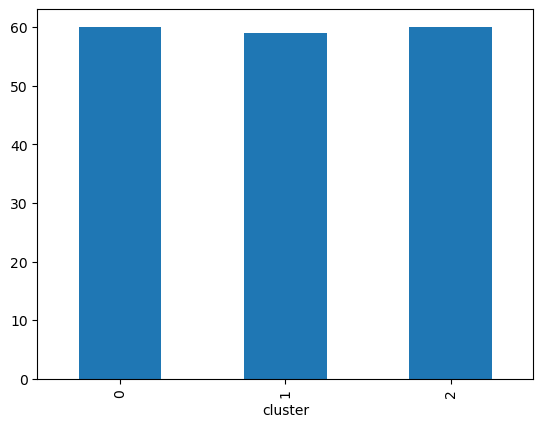

In [473]:
cust_data.groupby("cluster")["purchase_amount"].mean().plot(kind="bar")


<Axes: xlabel='cluster'>

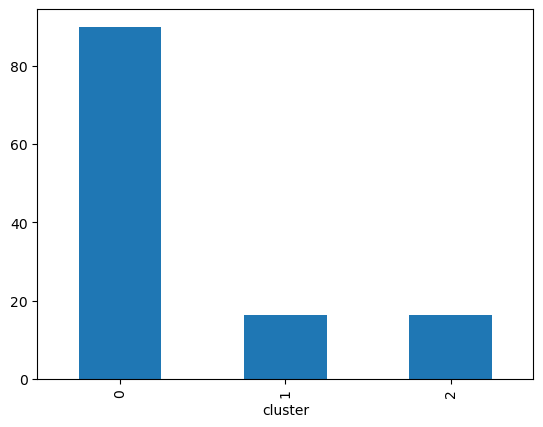

In [636]:
cust_data.groupby("cluster")["purchase_of_frequency_days"].mean().plot(kind="bar")


<Axes: xlabel='cluster'>

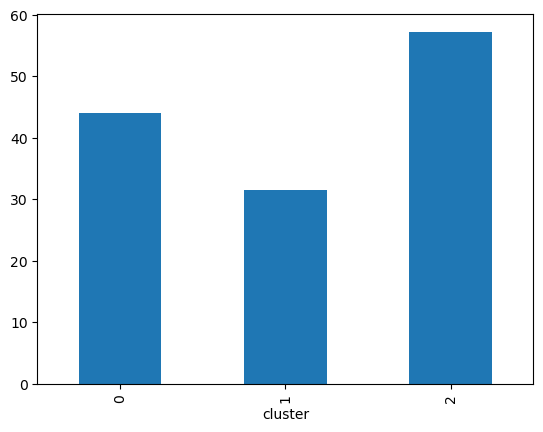

In [638]:
cust_data.groupby("cluster")["age"].mean().plot(kind="bar")


## Hierarchical Clustering

In [641]:
features = ['age','purchase_amount','previous_purchases','purchase_of_frequency_days']
X = cust_data[features]


In [643]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
from scipy.cluster.hierarchy import linkage

features = ['age','purchase_amount','previous_purchases','purchase_of_frequency_days']
X = cust_data[features]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create linkage matrix
Z = linkage(X_scaled, method='ward')

from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()



In [ ]:
from scipy.cluster.hierarchy import fcluster

cust_data['hier_cluster'] = fcluster(Z, t=3, criterion='maxclust')


In [ ]:
cust_data['hier_cluster'].value_counts()


In [ ]:
cust_data.groupby('hier_cluster')[features].mean().round(2)


## DBSCAN Clustering

In [ ]:
##  DBCAN
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors



nbrs = NearestNeighbors(n_neighbors=4).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])  # 4th nearest neighbor distances

plt.figure(figsize=(10,4))
plt.plot(distances)
plt.title("K-distance plot (Use to choose eps)")
plt.xlabel("Sorted points")
plt.ylabel("4th nearest distance")
plt.grid(True)
plt.show()

# Try eps=0.9 first (adjust if needed)
dbscan = DBSCAN(eps=0.9, min_samples=5)
cust_data['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster labels ( -1 = noise/outlier ):")
print(cust_data['dbscan_cluster'].value_counts())


Cluster counts (DBSCAN):
dbscan_cluster
0    2181
1    1147
Name: count, dtype: int64

DBSCAN Cluster Summary:
                customer_id    age  gender  purchase_amount  review_rating  \
dbscan_cluster                                                               
0                   1945.21  43.93    0.68            59.52           3.75   
1                   1955.46  44.03    0.69            60.03           3.75   

                previous_purchases  purchase_of_fequancy_days  pca1  pca2  \
dbscan_cluster                                                              
0                            25.28                      16.33 -0.21 -0.44   
1                            25.89                      90.00  0.40  0.84   

                dbscan_cluster  
dbscan_cluster                  
0                          0.0  
1                          1.0  


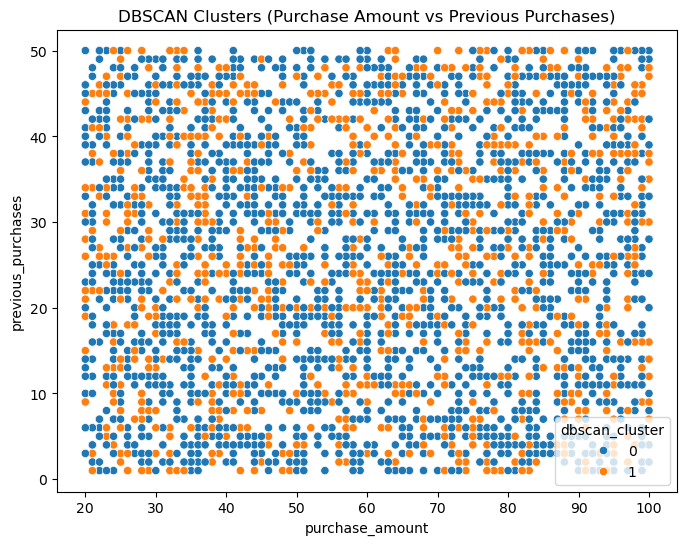

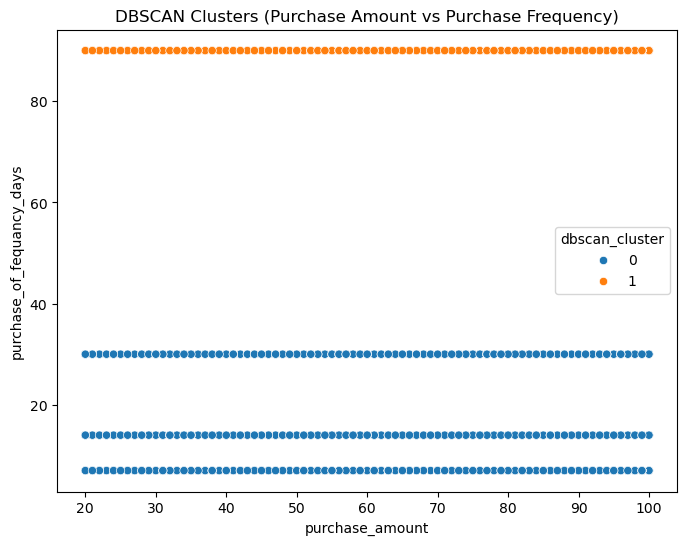

In [483]:
# ---------------- DBSCAN Cluster Summary ----------------

# Show cluster counts
print("Cluster counts (DBSCAN):")
print(cust_data['dbscan_cluster'].value_counts())

# Summary of numeric features for each DBSCAN cluster
numeric_cols = cust_data.select_dtypes(include=['int64','float64']).columns
summary_dbscan = cust_data.groupby('dbscan_cluster')[numeric_cols].mean().round(2)

print("\nDBSCAN Cluster Summary:")
print(summary_dbscan)

# 2D visual check: purchase_amount vs previous_purchases
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=cust_data,
    x='purchase_amount',
    y='previous_purchases',
    hue='dbscan_cluster',
    palette='tab10'
)
plt.title("DBSCAN Clusters (Purchase Amount vs Previous Purchases)")
plt.show()

# 2D visual check: purchase_amount vs purchase_frequency_days
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=cust_data,
    x='purchase_amount',
    y='purchase_of_fequancy_days',
    hue='dbscan_cluster',
    palette='tab10'
)
plt.title("DBSCAN Clusters (Purchase Amount vs Purchase Frequency)")
plt.show()


In [484]:
pd.crosstab(cust_data['cluster'], cust_data['dbscan_cluster'], normalize='index')
# or absolute counts
pd.crosstab(cust_data['cluster'], cust_data['dbscan_cluster'])


dbscan_cluster,0,1
cluster,,
0,0,1147
1,1131,0
2,1050,0


In [485]:
from sklearn.metrics import silhouette_score
labels = cust_data['dbscan_cluster'].values
mask = labels != -1
if mask.sum() > 0 and len(set(labels[mask])) > 1:
    print("Silhouette for non-noise points:", silhouette_score(X_scaled[mask], labels[mask]))
else:
    print("Silhouette not computed (not enough clusters/non-noise).")


Silhouette for non-noise points: 0.26866139197765465


In [486]:
outliers = cust_data[cust_data['dbscan_cluster']==-1]
outliers.head(20)


,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,payment_method,frequency_of_purchases,age_group,purchase_of_fequancy_days,cluster,pca1,pca2,customer_persona,hier_cluster,dbscan_cluster


## Cluster Persona Creation & Interpretation

In [487]:
cust_data.to_csv("customers_with_dbscan_labels.csv", index=False)
for lbl in sorted(cust_data['dbscan_cluster'].unique()):
    cust_data[cust_data['dbscan_cluster']==lbl].to_csv(f"cluster_dbscan_{lbl}.csv", index=False)


In [488]:
def cluster_summary(df, cols, label):
    s = df.groupby(label)[cols].agg(['mean','median','count']).round(2)
    return s

cols = ['age','purchase_amount','previous_purchases','purchase_of_frequency_days']
print("KMeans summary:")
display(cluster_summary(cust_data, cols, 'cluster'))
print("Hierarchical summary:")
display(cluster_summary(cust_data, cols, 'hier_cluster'))
print("DBSCAN summary:")
display(cluster_summary(cust_data, cols, 'dbscan_cluster'))


KMeans summary:


age              purchase_amount              previous_purchases  \
          mean median count            mean median count               mean   
cluster                                                                       
0        44.03   44.0  1147           60.03   61.0  1147              25.89   
1        31.55   31.0  1131           59.02   59.0  1131              23.33   
2        57.26   57.0  1050           60.05   60.0  1050              27.37   

                     purchase_of_fequancy_days               
        median count                      mean median count  
cluster                                                      
0         26.0  1147                     90.00   90.0  1147  
1         23.0  1131                     16.42   14.0  1131  
2         29.0  1050                     16.22   14.0  1050

Hierarchical summary:


age              purchase_amount               \
               mean median count            mean median count   
hier_cluster                                                    
1             44.03   44.0  1147           60.03   61.0  1147   
2             26.79   27.0   625           63.31   66.0   625   
3             50.81   51.0  1556           57.99   56.0  1556   

             previous_purchases              purchase_of_fequancy_days         \
                           mean median count                      mean median   
hier_cluster                                                                    
1                         25.89   26.0  1147                     90.00   90.0   
2                         20.94   19.0   625                     16.48   14.0   
3                         27.02   28.0  1556                     16.27   14.0   

                    
             count  
hier_cluster        
1             1147  
2              625  
3             1556

DBSCAN summary:


age              purchase_amount               \
                 mean median count            mean median count   
dbscan_cluster                                                    
0               43.93   44.0  2181           59.52   60.0  2181   
1               44.03   44.0  1147           60.03   61.0  1147   

               previous_purchases              purchase_of_fequancy_days  \
                             mean median count                      mean   
dbscan_cluster                                                             
0                           25.28   25.0  2181                     16.33   
1                           25.89   26.0  1147                     90.00   

                             
               median count  
dbscan_cluster               
0                14.0  2181  
1                90.0  1147

## SQL / Database Integration Preparation

In [489]:
!pip install psycopg2-binary sqlalchemy


In [490]:
# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual detail
from sqlalchemy import create_engine

username = "postgres"            
password = "180210102029%40Rp"             
host = "localhost"               
port = "5432"                    
database = "customer_trend_Analysis" 


engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "customer"    # choose any table name

cust_data.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'!")


Data successfully loaded into table 'customer' in database 'customer_trend_Analysis'!


In [491]:
cust_data.shape

(3328, 25)

In [500]:
cust_data.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_of_fequancy_days',
       'cluster', 'pca1', 'pca2', 'customer_persona', 'hier_cluster',
       'dbscan_cluster'],
      dtype='object')